# 01 — Exploratory Data Analysis корпусов

Статистика по processed-текстам Достоевского, Чехова и Булгакова:
- Размеры корпусов (книги, слова, уникальные слова, TTR)
- Распределение длин предложений
- POS-распределение
- Топ-30 слов по частоте
- Word clouds

Все графики сохраняются в `figures/eda/`.

In [1]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from razdel import tokenize, sentenize
import pymorphy3
from wordcloud import WordCloud

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['font.family'] = 'DejaVu Sans'

BASE = Path('..')
PROCESSED = BASE / 'data' / 'processed'
FIG_DIR = BASE / 'notebooks' / 'figures' / 'eda'
FIG_DIR.mkdir(parents=True, exist_ok=True)

AUTHORS = ['dostoevsky', 'chekhov', 'bulgakov']
AUTHOR_RU = {'dostoevsky': 'Достоевский', 'chekhov': 'Чехов', 'bulgakov': 'Булгаков'}
PALETTE = {'dostoevsky': '#C0392B', 'chekhov': '#2980B9', 'bulgakov': '#27AE60'}

print(f'Figures dir: {FIG_DIR.resolve()}')

Figures dir: /app/notebooks/figures/eda


## 1. Загрузка корпусов и базовая статистика

In [2]:
def load_corpus(author):
    files = sorted((PROCESSED / author).glob('*.txt'))
    texts = [f.read_text(encoding='utf-8') for f in files]
    return files, '\n\n'.join(texts)

corpus_stats = []
tokens_by_author = {}
sentences_by_author = {}

for author in AUTHORS:
    files, text = load_corpus(author)
    sents = [s.text for s in sentenize(text)]
    toks = [t.text.lower() for t in tokenize(text) if any(ch.isalpha() for ch in t.text)]
    corpus_stats.append({
        'Автор': AUTHOR_RU[author],
        'Книг': len(files),
        'Символов (млн)': round(len(text) / 1e6, 2),
        'Слов': len(toks),
        'Уникальных слов': len(set(toks)),
        'TTR': round(len(set(toks)) / max(len(toks), 1), 3),
        'Предложений': len(sents),
        'Средняя длина предложения (слов)': round(len(toks) / max(len(sents), 1), 1),
    })
    tokens_by_author[author] = toks
    sentences_by_author[author] = sents

stats_df = pd.DataFrame(corpus_stats).set_index('Автор')
display(stats_df)
stats_df.to_csv(FIG_DIR / 'corpus_stats.csv')

,Книг,Символов (млн),Слов,Уникальных слов,TTR,Предложений,Средняя длина предложения (слов)
Автор,,,,,,,
Достоевский,11,7.83,1218982,93566,0.077,87186,14.0
Чехов,14,9.08,1386242,105968,0.076,136969,10.1
Булгаков,17,0.96,148989,30073,0.202,16664,8.9


## 2. Распределение длин предложений

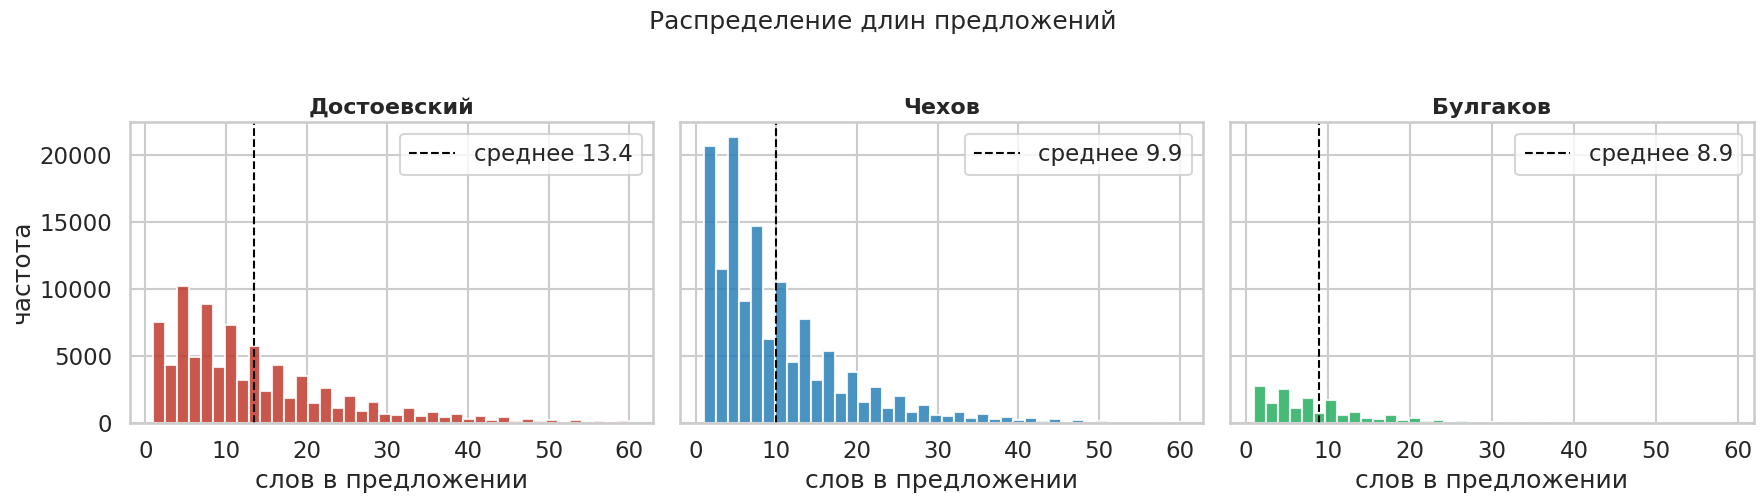

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, author in zip(axes, AUTHORS):
    lens = [len([t for t in tokenize(s) if any(c.isalpha() for c in t.text)])
            for s in sentences_by_author[author]]
    lens = [l for l in lens if 1 <= l <= 60]  # отсекаем выбросы
    ax.hist(lens, bins=40, color=PALETTE[author], edgecolor='white', alpha=0.85)
    mean = np.mean(lens)
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.5, label=f'среднее {mean:.1f}')
    ax.set_title(AUTHOR_RU[author], fontsize=16, fontweight='bold')
    ax.set_xlabel('слов в предложении')
    ax.legend()
axes[0].set_ylabel('частота')
fig.suptitle('Распределение длин предложений', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. POS-распределение по авторам

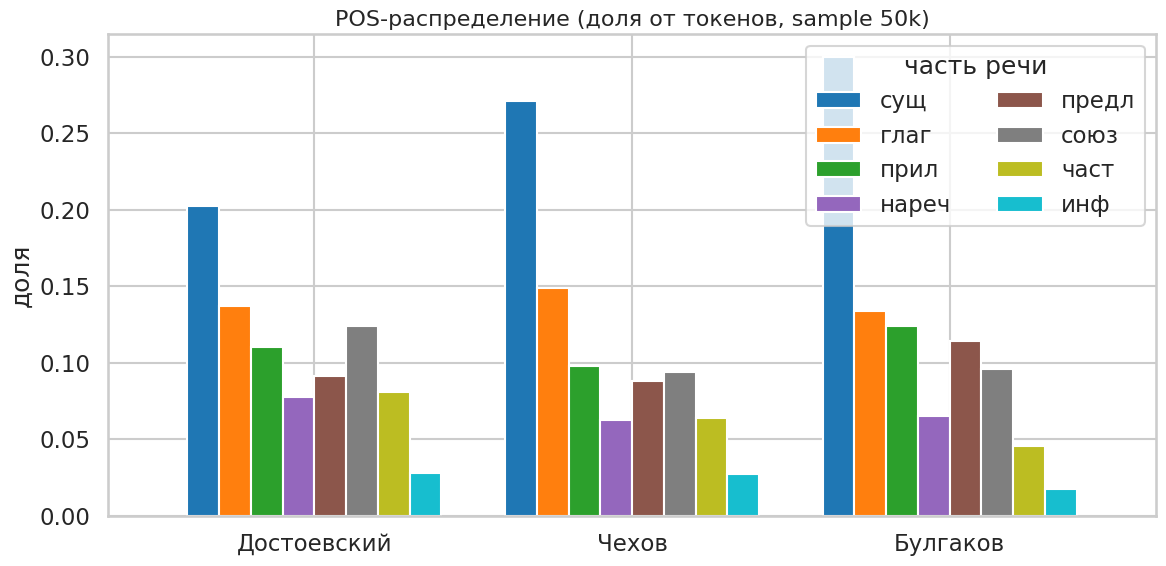

,сущ,глаг,прил,нареч,предл,союз,част,инф
Достоевский,0.203,0.137,0.110,0.077,0.091,0.124,0.081,0.028
Чехов,0.271,0.149,0.098,0.062,0.088,0.094,0.064,0.027
Булгаков,0.300,0.134,0.124,0.065,0.114,0.096,0.046,0.017


In [4]:
morph = pymorphy3.MorphAnalyzer()
POS_TAGS = ['NOUN', 'VERB', 'ADJF', 'ADVB', 'PREP', 'CONJ', 'PRCL', 'INFN']
POS_RU = {'NOUN': 'сущ', 'VERB': 'глаг', 'ADJF': 'прил', 'ADVB': 'нареч',
          'PREP': 'предл', 'CONJ': 'союз', 'PRCL': 'част', 'INFN': 'инф'}

# Считаем на sample из 50k токенов на автора — быстрее и репрезентативно
SAMPLE_SIZE = 50_000
pos_dist = {}
for author in AUTHORS:
    toks = tokens_by_author[author][:SAMPLE_SIZE]
    counts = Counter()
    for t in toks:
        parse = morph.parse(t)
        if parse and parse[0].tag.POS:
            counts[parse[0].tag.POS] += 1
    total = sum(counts.values()) or 1
    pos_dist[author] = {tag: counts.get(tag, 0) / total for tag in POS_TAGS}

df = pd.DataFrame(pos_dist).T
df.index = [AUTHOR_RU[a] for a in df.index]
df.columns = [POS_RU[c] for c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
df.plot(kind='bar', ax=ax, width=0.8, colormap='tab10')
ax.set_title('POS-распределение (доля от токенов, sample 50k)', fontsize=16)
ax.set_ylabel('доля')
ax.set_xlabel('')
ax.legend(title='часть речи', loc='upper right', ncols=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
display(df.round(3))

## 4. Топ-30 слов по частоте (без стоп-слов)

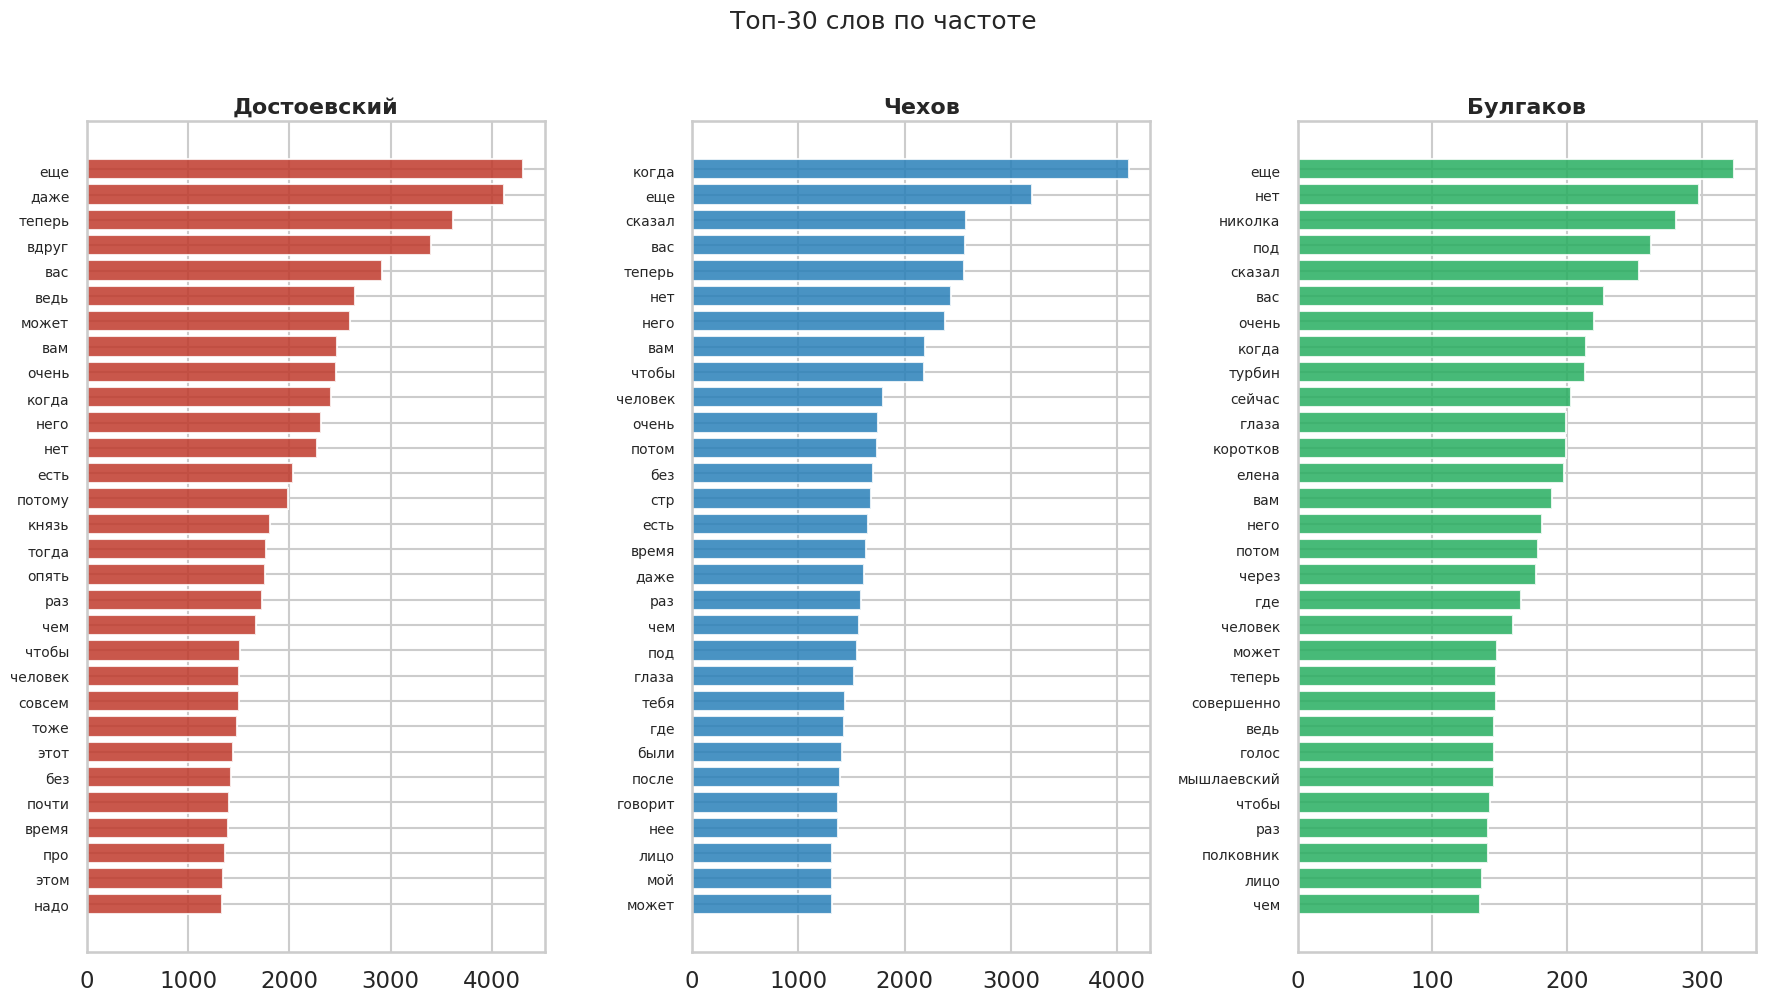

In [5]:
STOPWORDS_RU = set("""
и в не на с я он но она по как к это то что же а за из у о все был была было они ему ей её от до
для или бы если мы ты вы уже так ли быть тебе меня только свой свои моё её его уже при ещё
ему мне тем той там тут вот ни да же б ей моё меня ничего того этому этой этим этой такую
всё этого той тот та те себя себе собой который которая которое которые сам самого самой
""".split())

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for ax, author in zip(axes, AUTHORS):
    c = Counter(t for t in tokens_by_author[author] if t not in STOPWORDS_RU and len(t) > 2)
    top = c.most_common(30)
    words, counts = zip(*reversed(top))
    ax.barh(words, counts, color=PALETTE[author], alpha=0.85)
    ax.set_title(AUTHOR_RU[author], fontsize=16, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
fig.suptitle('Топ-30 слов по частоте', fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Word clouds

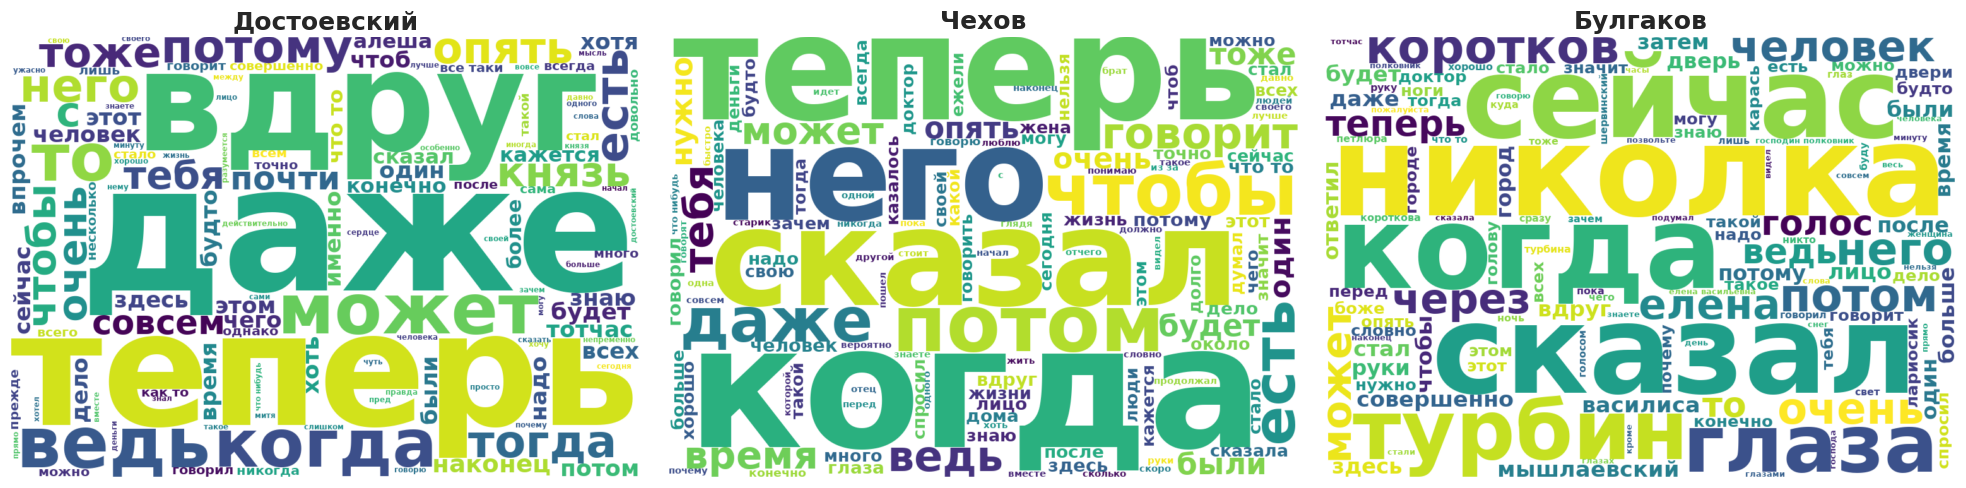

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, author in zip(axes, AUTHORS):
    text = ' '.join(t for t in tokens_by_author[author] if t not in STOPWORDS_RU and len(t) > 3)
    wc = WordCloud(width=1000, height=700, background_color='white',
                   max_words=120, colormap='viridis',
                   font_path='/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(AUTHOR_RU[author], fontsize=18, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'wordclouds.png', dpi=120, bbox_inches='tight')
plt.show()

---
**Итого:** все графики сохранены в `ml/notebooks/figures/eda/` — готовы для вставки в диплом.